In [381]:
# Importar librerías
import seaborn as sns   
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd

from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
import optuna
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
import joblib

# Importar utils
import sys
sys.path.append('src')
from utils.bootcampviztools import *
from utils.toolbox import *

pd.options.mode.copy_on_write = True # CoW por defecto a partir de Pandas 3.0.0

In [382]:
# Cargamos los datos
df = pd.read_parquet('src/data_sample/datos_licitaciones.parquet', engine='fastparquet')

In [383]:
# Exploramos los datos
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37700 entries, 572837 to 2087811
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Situació contractual                 37700 non-null  object 
 1   Exercici                             37700 non-null  int64  
 2   Àmbit organitzatiu                   37700 non-null  object 
 3   Identificador agrupació organisme    37700 non-null  object 
 4   Agrupació organisme                  37700 non-null  object 
 5   Identificador organisme contractant  37700 non-null  object 
 6   Organisme contractant                37700 non-null  object 
 7   Codi de l’expedient                  37700 non-null  object 
 8   Procediment d’adjudicació            37700 non-null  object 
 9   Tipus de contracte                   37700 non-null  object 
 10  Descripció de l’expedient            37700 non-null  object 
 11  Número de lot             

In [384]:
'''
Antes de hacer el split dedidimos cuál es nuestra target 
'''

# Nuestro proyecto se centrará en predecir el importe de la liquidación, por lo que nos quedamos con esa variable como target.
target = 'Import de la liquidació'

In [385]:
# Vemos la distribución de la variable objetivo
df[target].describe()

count    3.770000e+04
mean     2.871306e+03
std      2.989103e+04
min     -3.570100e+02
25%      1.458950e+02
50%      4.800000e+02
75%      1.620000e+03
max      4.013769e+06
Name: Import de la liquidació, dtype: float64

In [386]:
'''
Observamos que hay valores negativos en nuestra target.
Vamos a ver de qué % se trata
'''

# Registros con valor target <=0 
negativos = df[df[target] <= 0].shape[0]
print(f"Registros con valor {target} <= 0: {negativos} {negativos/df.shape[0]*100:.2f}%")

Registros con valor Import de la liquidació <= 0: 47 0.12%


In [387]:
'''
Como se trata solamente de un 0,12%, decidimos excluirlos del fichero para no añadir ruido al modelo
'''

# Eliminar los registros donde el valor de la variable target es menor a 0
# los trataremos una vez entrenado el modelo
df_copia = df[df[target] > 0]
print(f"Registros restantes: {len(df_copia)}")

Registros restantes: 37653


<Axes: xlabel='Import de la liquidació', ylabel='Count'>

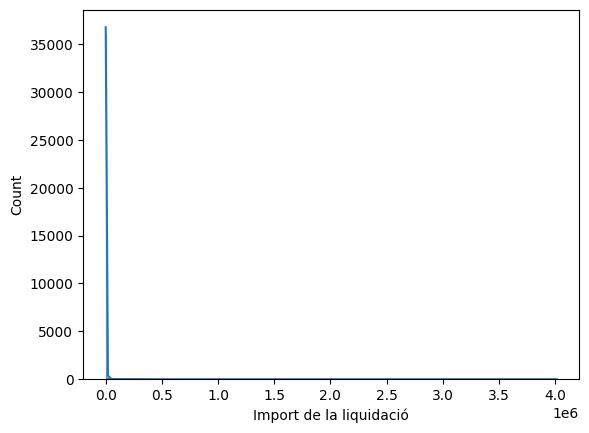

In [388]:
# Estudiamos la distribución de la target después de eliminar los registros con valor <= 0
sns.histplot(df_copia[target], kde=True)

<Axes: xlabel='Import de la liquidació_log', ylabel='Count'>

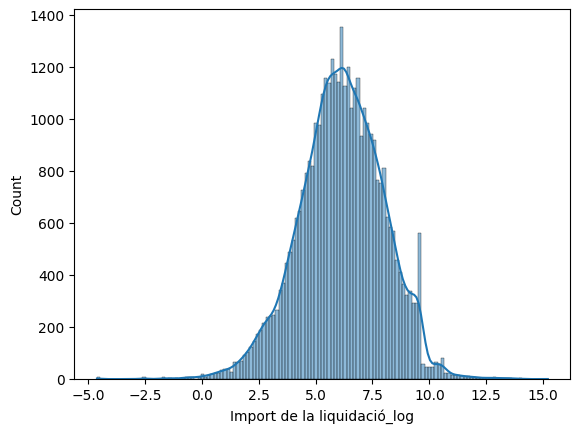

In [389]:
'''
Tiene una distribución muy sesgada, como no hay negativos le aplicamos el logaritmo
'''

# Aplicamos logaritmo a la variable target para reducir su asimetría
# Nuestra nueva variable target será target_log
target_log = target + '_log'
df_copia.loc[:, target_log] = np.log(df_copia[target])
sns.histplot(df_copia[target_log], kde=True)

Vemos como después de aplicar el logaritmo a nuestra target, la distribución se ha normalizado

In [390]:
# Hacemos el split
X_train, X_test, y_train, y_test = train_test_split(df_copia.drop([target, target_log], axis=1),
                                                     df_copia[target_log],
                                                     test_size=0.2,
                                                     random_state=42)

In [391]:
'''
Vamos a almacenar todos los cambios que hagamos en X_train en una especie de pipeline
para después poder aplicarlo a X_test y a nuevos datos que queramos predecir con el modelo
'''

# Inicializamos la lista de pasos del pipeline
pipeline_steps = []

In [392]:

'''
Antes de nada, vemos que el fichero usa el idioma Catalán, 
por lo que vamos a eliminar apóstrofes, acentos... tanto de columnas como datos
para facilitar su manejo.
'''

# Eliminar todos los apóstrofes de los nombres de columnas y de los datos tipo string y pasar a minúsculas
tratar_strings(X_train)
pipeline_steps.append(lambda df: tratar_strings(df))

In [393]:
# Tratamiento Missings
data_report(X_train).sort_values(by='MISSINGS (%)', ascending=False)

,DATA_TYPE,MISSINGS (%),UNIQUE_VALUES,CARDIN (%)
COL_N,,,,
Termini_modificacio_anys,float64,100.0,0,0.00
Import_de_la_modificacio,float64,100.0,0,0.00
Numero_de_modificacio,float64,100.0,0,0.00
Numero_de_prorroga,float64,100.0,0,0.00
Termini_modificacio_mesos,float64,100.0,0,0.00
Termini_modificacio_dies,float64,100.0,0,0.00
Exercici,int64,0.0,9,0.03
Situacio_contractual,object,0.0,1,0.00
Ambit_organitzatiu,object,0.0,3,0.01


In [394]:
# Vemos que hay columnas con un alto porcentaje de missings
# Decidimos eliminar las columnas con más del 60% de valores nulos
eliminar_columnas_nulas(X_train, pipeline_steps)

Total de columnas vacías: 10

Se elimina columna: Numero_de_prorroga
Se elimina columna: Data_inici_prorroga
Se elimina columna: Data_fi_prorroga
Se elimina columna: Numero_de_modificacio
Se elimina columna: Tipus_de_modificacio
Se elimina columna: Import_de_la_modificacio
Se elimina columna: Data_aprovacio_modificacio
Se elimina columna: Termini_modificacio_anys
Se elimina columna: Termini_modificacio_mesos
Se elimina columna: Termini_modificacio_dies


In [395]:
# Ahora trataremos columnas con algún valor en blanco, eliminaremos las que tienen más del 70% en blanco
# Para el resto informamos el valor 'Desconocido'
tratar_columnas_con_algun_blanco(X_train, pipeline_steps, val='Desconocido')

Columnas con algún blanco:

Columna con blancos: Procediment_dadjudicacio 16 0.05%
Columna con blancos: Codi_CPV 19749 65.56%
Se elimina columna: Causa_de_resolucio 30113 99.97%


In [396]:
# Estudio cardinalidades
data_report(X_train).sort_values(by='UNIQUE_VALUES')

,DATA_TYPE,MISSINGS (%),UNIQUE_VALUES,CARDIN (%)
COL_N,,,,
Situacio_contractual,object,0.0,1,0.00
Lot_desert,object,0.0,1,0.00
Tipus_de_liquidacio,object,0.0,2,0.01
Ambit_organitzatiu,object,0.0,3,0.01
Durada_anys,int64,0.0,5,0.02
Tipus_de_contracte,object,0.0,7,0.02
Procediment_dadjudicacio,object,0.0,8,0.03
Exercici,int64,0.0,9,0.03
Durada_mesos,int64,0.0,15,0.05


In [397]:
'''
Podemos observar que todas las filas tienen el mismo tipo de situación contractual y Lot_desert, 
ya que su cardinalidad es 0, no nos aporta ningún tipo de información, por tanto, decidimos eliminarlas.

También vemos que hay otras columnas con un alto número de valores únicos, 
lo que puede dificultar el entrenamiento del modelo, por lo que decidimos eliminarlas también.

'''
# Eliminar las columnas con cardinalidad 0 o mayor que 60%
tratar_cardinalidad(X_train, pipeline_steps)

Total de columnas con cardinalidad 0 o mayor que 60.0%: 5

Se elimina columna: Situacio_contractual (1 valores únicos, 0.00%)
Se elimina columna: Lot_desert (1 valores únicos, 0.00%)
Se elimina columna: Codi_de_lexpedient (29824 valores únicos, 99.01%)
Se elimina columna: Descripcio_de_lexpedient (25317 valores únicos, 84.05%)
Se elimina columna: Descripcio_del_lot (25318 valores únicos, 84.05%)


In [398]:
'''
Con respecto a la columna 'Exercici', si bien se trata ya de una feature numerica, para mejorar el rendimiento del modelo, 
aplicaremos una transformación para que el modelo no interprete siempre estos valores
como año, dado que el modelo no entiende lo que son, solo que son modelos 

'''
# X_train.iloc[:, 0].value_counts().sort_values()

# clave_Exercici = {año: i for i, año in enumerate(range(2007, 2031))}

# X_train["Exercici"] = X_train["Exercici"].map(clave_Exercici)

# pipeline_steps.append(lambda df: df.assign(Exercici=df["Exercici"].map(clave_Exercici)))


"\nCon respecto a la columna 'Exercici', si bien se trata ya de una feature numerica, para mejorar el rendimiento del modelo, \naplicaremos una transformación para que el modelo no interprete siempre estos valores\ncomo año, dado que el modelo no entiende lo que son, solo que son modelos \n\n"

In [399]:
X_train["Ambit_organitzatiu"].value_counts().sort_values()

Ambit_organitzatiu
universitats                                                    3214
departaments i sector public de la generalitat de catalunya     9838
entitats de ladministracio local                               17070
Name: count, dtype: int64

In [400]:
'''
Con respecto a la columna 'Ambit_organitzatiu', haremos un diccionario
para asignar un valor numérico a cada categoría, 
ya que se trata de una variable categórica
'''

clave_Ambit_organitzatiu = {
    "universitats": 1,
    "departaments i sector public de la generalitat de catalunya": 2,
    "entitats de ladministracio local": 3
}

X_train["Ambit_organitzatiu"] = X_train["Ambit_organitzatiu"].map(clave_Ambit_organitzatiu)

pipeline_steps.append(lambda df: df.assign(Ambit_organitzatiu=df["Ambit_organitzatiu"].map(clave_Ambit_organitzatiu)))

In [401]:
'''
Hemos descubierto que el campo "Identificador agrupació organisme" no se trata de un numero aleatorio, en realidad, tiene su propia nomenclatura, los primeros dos digitos
hacen referencia a la dirección postal del lugar de la licitación, por lo que podemos añadir una columna adicional a partir de esta, mas explicativa que el organismo contratante,
para identificar el lugar de la licitacion. En concreto, los codigos 08,17,25,43 hacen referencia a las direcciones postales de Barcelona, Girona, LLeida y Tarragona.
El resto de valores que no entran en estas caracteristicas, se tratan de organizaciones que no comprende este indice, y se hara una transformacion a parte
'''
identificador_agrupacio_organisme(X_train)
pipeline_steps.append(lambda df: identificador_agrupacio_organisme(df))


In [402]:
'''
Tambien eliminaremos la columna agrupació organisme, identificador organisme, i organisme contractant, 
dada la transformación anterior que nos permite generalizar 
mucho mejor estos datos
'''
X_train.drop("Agrupacio_organisme", axis = 1, inplace = True)
X_train.drop("Identificador_organisme_contractant", axis = 1, inplace = True)
X_train.drop("Organisme_contractant", axis = 1, inplace = True)

pipeline_steps.append(lambda df, col="Agrupacio_organisme": df.drop(col, axis=1))
pipeline_steps.append(lambda df, col="Identificador_organisme_contractant": df.drop(col, axis=1))
pipeline_steps.append(lambda df, col="Organisme_contractant": df.drop(col, axis=1))

In [403]:
'''
Sobre la feature "Procediment_dadjudicacio"
Vemos que tiene una estructura muy irregular, podemos transformar todos los valores menores en 0, y el resto ponerlo ponerlos en 1 
'''

X_train["Procediment_dadjudicacio"] = np.where(
    X_train["Procediment_dadjudicacio"] =="menor",
    True,
    False
)

pipeline_steps.append(
    lambda df: df.assign(
        Procediment_dadjudicacio=np.where(
            df["Procediment_dadjudicacio"] == "menor", True, False
        )
    )
)

In [404]:
print(X_train["Tipus_de_contracte"].value_counts())


Tipus_de_contracte
5. serveis                           16457
3. subministraments                  12766
1. obres                               889
10. privat dadministracio publica        5
subministraments                         3
gestio de servei public                  1
8. concessio de serveis                  1
Name: count, dtype: int64


In [405]:
'''
Tipus de contracte 
Nuevamente una columna categorica, que podemos aplicar un mapeado para facilitar el proceso del modelo 
'''

tipus_de_contracte(X_train)
pipeline_steps.append(lambda df: tipus_de_contracte(df))

In [406]:
'''
Numero_de_lot
Esta columna esta perfecta tal y como viene, y no es neceario aplicar transformaciones.
'''

X_train['Numero_de_lot'].value_counts().sort_values(ascending= False)


Numero_de_lot
1     30034
2        36
4        12
3        12
5         5
7         4
6         3
9         2
8         2
24        1
47        1
15        1
35        1
59        1
32        1
27        1
25        1
10        1
13        1
16        1
53        1
Name: count, dtype: int64

In [407]:
'''
El codigo cpv contiene información muy interesante acerca del ambito al que se pueda referir la licitacion, 
para ello necesitamos hacer una transformacion de la columna, y 
procesar los datos
'''

# Codi CPV
# https://contratos.gobierto.es/cpv
# https://www.licitaciones.es/blog/codigos-cpv
# https://record.bibliotecadigital.gencat.cat/handle/20.500.14345/2167

# Fichero con la definición de códigos CPV
# with open('src/data_sample/Codigos_CPV.txt', 'r', encoding= "utf-8") as f:
#     lineas = f.readlines()

# datos = [linea.strip().split(' - ', 1) for linea in lineas]
# df_CPV = pd.DataFrame(datos, columns=['Codi_CPV', 'Descripcio_CPV'])
# df_CPV["Codi_CPV"] = df_CPV["Codi_CPV"].astype(str).str.strip().str.zfill(8)

df_CPV = pd.read_csv('src/data_sample/Codigos_CPV.csv', sep=';')
df_CPV["CPV_def"] = df_CPV["CPV_def"].astype(str).str.zfill(8)

X_train = codi_cpv(X_train, df_CPV)
pipeline_steps.append(lambda df: codi_cpv(df, df_CPV))


In [408]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30122 entries, 0 to 30121
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Exercici                  30122 non-null  int64  
 1   Ambit_organitzatiu        30122 non-null  int64  
 2   Procediment_dadjudicacio  30122 non-null  bool   
 3   Tipus_de_contracte        30122 non-null  int64  
 4   Numero_de_lot             30122 non-null  int64  
 5   Codi_CPV                  30122 non-null  object 
 6   Adjudicatari              30122 non-null  object 
 7   Import_dadjudicacio       30122 non-null  float64
 8   Data_dadjudicacio         30122 non-null  object 
 9   Durada_dies               30122 non-null  int64  
 10  Durada_mesos              30122 non-null  int64  
 11  Durada_anys               30122 non-null  int64  
 12  Tipus_de_liquidacio       30122 non-null  object 
 13  Data_de_liquidacio        30122 non-null  object 
 14  Refere

In [409]:
# Comprovamos las columnas CPV añadidas para ver que no hayan nulos
X_train['CPV_Descripcion'].value_counts().sort_values(ascending=False)

CPV_Descripcion
Desconodido                                                                         19749
Productos farmacéuticos                                                               889
Servicios de formación especializada                                                  440
Servicios de reparación y mantenimiento                                               425
Equipamiento y artículos médicos, farmacéuticos y de higiene personal                 332
                                                                                    ...  
Servicios de gestión de datos                                                           1
Taquillas                                                                               1
Alisadoras de asfalto                                                                   1
Estatuillas, objetos de adorno, marcos para fotografías o para cuadros y espejos        1
Servicios de instalación de equipos mecánicos                                       

In [410]:
X_train['Tipo_de_contrato'].value_counts().sort_values(ascending=False)

Tipo_de_contrato
Desconocido    19749
Suministros     5074
Servicios       4706
Obras            593
Name: count, dtype: int64

In [411]:
X_train['Codi_CPV_div'].value_counts().sort_values(ascending=False)

Codi_CPV_div
00    19749
33     2206
79      932
80      887
50      685
45      593
92      504
71      416
44      359
30      344
39      328
31      284
34      234
22      214
72      212
98      207
32      190
38      183
42      154
85      140
90      130
55      105
48      102
18       98
60       98
63       89
24       66
77       58
09       58
73       56
75       52
35       48
15       46
64       41
37       40
43       39
03       38
66       32
51       27
70       23
19       15
14       15
16       12
65       11
41        1
76        1
Name: count, dtype: int64

In [412]:
'''
Una vez hecho el procesado de esta columna, podemos eliminar las columnas de información relativa para evitar
ruido en el modelo. Por desgracia, esta columna no estaba complimentada originalmente, por lo que debemos
generalizar en los nulos, poniendo "Desconocido", en cada uno de ellos
'''

X_train.drop(columns=['Codi_CPV', 'CPV_def'], inplace=True)
pipeline_steps.append(lambda df, col=['Codi_CPV', 'CPV_def']: df.drop(col, axis=1))


In [413]:
'''
Ahora queda transformar la feature en numerico para que facilite el procesado el modelo, ademas viendo el value couunts, podemos observar que la variable sera sensible 
a la escala, asi que es mejor hacer el procesado de esta forma. Para transformarla, haremos uso de una funcion de frecuencia
'''

freq_CPV = X_train["CPV_Descripcion"].value_counts(normalize=True)
X_train["CPV_Descripcion"] = X_train['CPV_Descripcion'].map(freq_CPV)
pipeline_steps.append(lambda df: df.assign(CPV_Descripcion=df['CPV_Descripcion'].map(freq_CPV)))

freq_Tipo_de_contrato = X_train["Tipo_de_contrato"].value_counts(normalize=True)
X_train["Tipo_de_contrato"] = X_train['Tipo_de_contrato'].map(freq_Tipo_de_contrato)
pipeline_steps.append(lambda df: df.assign(Tipo_de_contrato=df['Tipo_de_contrato'].map(freq_Tipo_de_contrato)))

freq_CPV_div = X_train["Codi_CPV_div"].value_counts(normalize=True)
X_train["Codi_CPV_div"] = X_train['Codi_CPV_div'].map(freq_CPV_div)
pipeline_steps.append(lambda df: df.assign(Codi_CPV_div=df['Codi_CPV_div'].map(freq_CPV_div)))

In [414]:
'''
La siguiente columna es una interesante, si bien en un principio aparenta ser una columna de texto libre, y podriamos hacer uso de una funcion de frecuencia, es interesante
que los nombres de las empresas aparezcan multiples veces, escritos de forma diferente. La funcion de frecuencia no es la ideal, pero otras optativas como el tfidf nos genera 
una dimensionalidad enorme, por lo que usaremos la funcion de frecuencia, pese a no ser la ideal

'''
freq_adj = X_train["Adjudicatari"].value_counts(normalize=True)
X_train["Adjudicatari"] = X_train['Adjudicatari'].map(freq_adj)
pipeline_steps.append(lambda df: df.assign(Adjudicatari=df['Adjudicatari'].map(freq_adj)))

In [415]:
'''
No transformaremos ni modificaremos la columna de "Import d'adjudicacio" dado que esta en un formato muy conveniente,
Sin embargo, sospechamos que la mayoría de valores de esta columna coiciden con nuestra target, vamos a ver el % de coincidencia
Para ello usaremos el df inicial que contiene nuestra target sin la transformación logarítmica
'''
similitud_con_target(df, df[target], ["Import d’adjudicació"], pipeline_steps)

Porcentage coincidencia Import d’adjudicació / Import de la liquidació: 97.28%
Se debería eliminar la columna: Import d’adjudicació


In [416]:
# Eliminamos la columna de "Import d'adjudicacio" dado que coincide en un 99% con nuestra target, y no aporta información adicional            df.drop(columns=[col], inplace=True)
X_train.drop('Import_dadjudicacio', axis = 1, inplace = True)
pipeline_steps.append(lambda df, col='Import_dadjudicacio': df.drop(col, axis=1))

In [417]:
'''
Para la transformacion de la siguiente columnas, que se trata de fechas, en formato de europa, decidimos transformar los numeros en unix timestamp,
y luego, crear columnas adicionales para representar el dia, mes y año, que tratan, asi al modelo no le afectara la escala de los datos, y no le 
dejaremos la libre interpretacion de la distancia entre fechas(por ejemplo del 28/02/2026 a 01/03/2026, se trata de una diferencia minuscula,
pero estos valores no los interpreta )
'''
fechas(X_train)
pipeline_steps.append(lambda df: fechas(df))



Fechas incongruentes Data_de_liquidacio: 
5489    30/04/0022
9814    12/06/0024
Name: Data_de_liquidacio, dtype: object

Fechas corregidas: Data_de_liquidacio
30/04/2022
12/06/2024


In [418]:
# Fechas futuras
X_train[X_train['year_Data_de_liquidacio'] > pd.Timestamp.today().normalize().year]

,Exercici,Ambit_organitzatiu,Procediment_dadjudicacio,Tipus_de_contracte,Numero_de_lot,Adjudicatari,Durada_dies,Durada_mesos,Durada_anys,Tipus_de_liquidacio,...,CPV_Descripcion,Tipo_de_contrato,day_Data_dadjudicacio,month_Data_dadjudicacio,year_Data_dadjudicacio,unix_Data_dadjudicacio,day_Data_de_liquidacio,month_Data_de_liquidacio,year_Data_de_liquidacio,unix_Data_de_liquidacio
3986,2025,3,True,2,1,0.008067,0,0,0,compliment,...,0.655634,0.655634,22,7,2025,1753142400,22,7,2027,1816214400
10596,2025,3,True,1,1,0.000033,0,0,0,compliment,...,0.655634,0.655634,22,7,2025,1753142400,22,7,2027,1816214400
13008,2025,3,True,2,1,0.008067,0,0,0,compliment,...,0.655634,0.655634,22,7,2025,1753142400,22,7,2027,1816214400
19673,2025,3,True,2,1,0.000033,0,0,0,compliment,...,0.655634,0.655634,22,7,2025,1753142400,22,7,2027,1816214400
19977,2022,3,True,3,1,0.000033,0,1,0,compliment,...,0.000133,0.168448,25,8,2022,1661385600,16,10,2031,1949875200
20638,2022,3,True,2,1,0.000033,2,1,0,compliment,...,0.000266,0.168448,28,11,2022,1669593600,31,12,2202,7352640000
26148,2025,3,True,2,1,0.008067,0,0,0,compliment,...,0.655634,0.655634,22,7,2025,1753142400,22,7,2027,1816214400
28116,2025,3,True,2,1,0.000199,0,0,0,compliment,...,0.655634,0.655634,22,7,2025,1753142400,22,7,2027,1816214400


In [419]:
''' 
Nos llama la atención la el valor 2202 en la columna 'year_Data_de_liquidacio' 
Dado que la licitación se adjudicó en 2022. Suponemos que se trata de un error
y que en realidad es 2022 y lo arreglamos a mano
'''
error_years = list(X_train[X_train['year_Data_de_liquidacio'] > 2050].index)
for idx in error_years:
    X_train.loc[idx, 'year_Data_de_liquidacio'] = X_train.loc[idx, 'Exercici']


In [420]:
'''
Las siguientes columnas muestran el tiempo que estuvo ejecutandose la licitacion, separada en dias, meses, y años.
Decidimos hacer una transformacion en una sola columna para transformarlas todas en dias (facilita la interpretabilidad
del modelo)
'''
duracion(X_train)
pipeline_steps.append(lambda df: duracion(df))



In [421]:
X_train['Tipus_de_liquidacio'].value_counts()

Tipus_de_liquidacio
compliment    30113
resolucio         9
Name: count, dtype: int64

In [422]:
'''
Para el tipo de liquidacion seguimos el mismo comportamiento que antes, los pesos estan muy desbalanceados, asi que
lo convertiremos en booleano
'''

X_train["Tipus_de_liquidacio"] = np.where(
    X_train["Tipus_de_liquidacio"] =="compliment",
    True,
    False
)

pipeline_steps.append(
    lambda df: df.assign(
        Tipus_de_liquidacio=np.where(
            df["Tipus_de_liquidacio"] == "compliment", True, False
        )
    )
)

In [423]:
# Vemos cómo ha quedado el dataset después de todas las transformaciones
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30122 entries, 0 to 30121
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Exercici                  30122 non-null  int64  
 1   Ambit_organitzatiu        30122 non-null  int64  
 2   Procediment_dadjudicacio  30122 non-null  bool   
 3   Tipus_de_contracte        30122 non-null  int64  
 4   Numero_de_lot             30122 non-null  int64  
 5   Adjudicatari              30122 non-null  float64
 6   Tipus_de_liquidacio       30122 non-null  bool   
 7   Referencia_Licitacio      30122 non-null  int64  
 8   Codi_CPV_div              30122 non-null  float64
 9   CPV_Descripcion           30122 non-null  float64
 10  Tipo_de_contrato          30122 non-null  float64
 11  day_Data_dadjudicacio     30122 non-null  int32  
 12  month_Data_dadjudicacio   30122 non-null  int32  
 13  year_Data_dadjudicacio    30122 non-null  int32  
 14  unix_D

In [424]:
'''
Ahora que hemos hecho una limpieza, toca hacer un pequeño eda para ver si es necesario 
hacer alguna estandarización, ver la distribucion entre otras cosas
Sólo tenemos features numèricas o booleanas
'''

# Separar columnas numéricas, objeto y fecha
features_numericas = X_train.select_dtypes(include=['number']).columns
features_booleanas = X_train.select_dtypes(include=['bool']).columns



In [425]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Exercici,30122.0,2.022548e+03,1.240784e+00,2.010000e+03,2.021000e+03,2.022000e+03,2.023000e+03,2.026000e+03
Ambit_organitzatiu,30122.0,2.459996e+00,6.795689e-01,1.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00
Tipus_de_contracte,30122.0,1.483733e+00,5.575219e-01,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,6.000000e+00
Numero_de_lot,30122.0,1.017562e+00,6.678757e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.900000e+01
Adjudicatari,30122.0,3.402492e-04,8.649696e-04,3.319833e-05,3.319833e-05,6.639665e-05,2.323883e-04,8.067193e-03
Referencia_Licitacio,30122.0,3.623797e+00,2.775528e+00,1.000000e+00,1.000000e+00,3.000000e+00,5.000000e+00,1.300000e+01
Codi_CPV_div,30122.0,4.393367e-01,2.988253e-01,3.319833e-05,3.094084e-02,6.556338e-01,6.556338e-01,6.556338e-01
CPV_Descripcion,30122.0,4.316862e-01,3.090520e-01,3.319833e-05,4.182989e-03,6.556338e-01,6.556338e-01,6.556338e-01
Tipo_de_contrato,30122.0,4.830262e-01,2.389896e-01,1.968661e-02,1.684483e-01,6.556338e-01,6.556338e-01,6.556338e-01
day_Data_dadjudicacio,30122.0,1.624842e+01,9.128714e+00,1.000000e+00,8.000000e+00,1.600000e+01,2.400000e+01,3.100000e+01


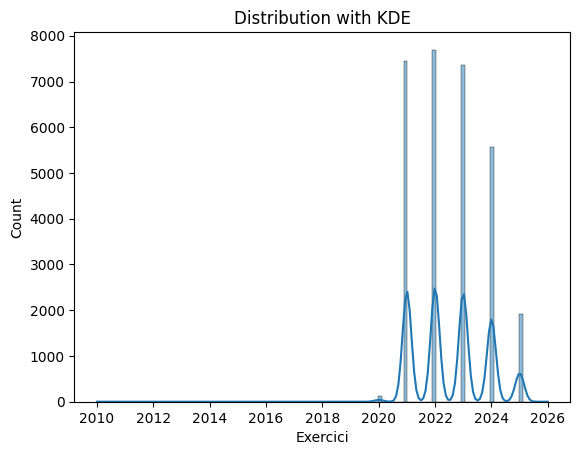

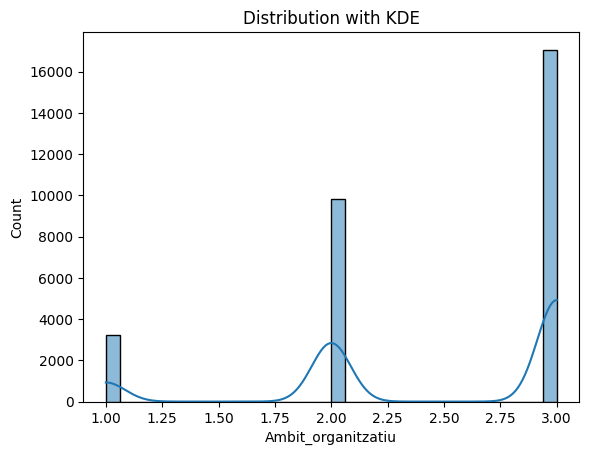

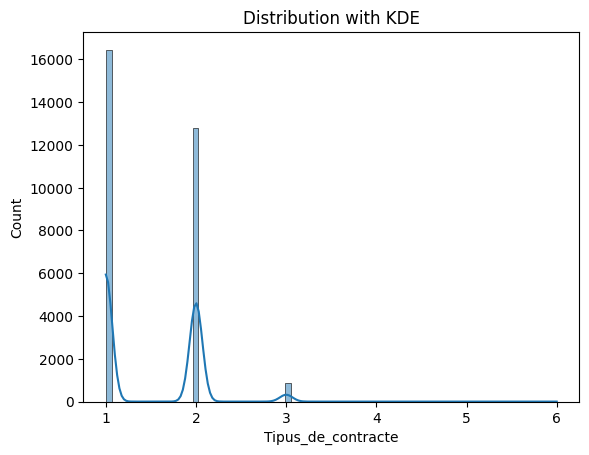

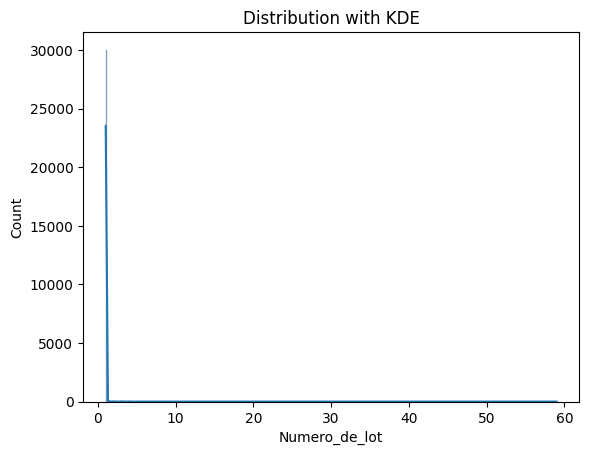

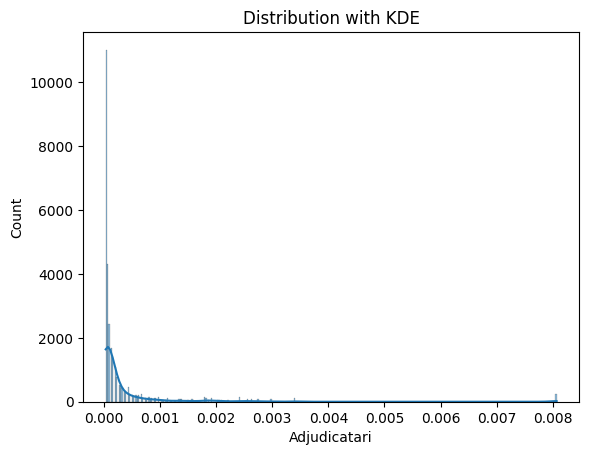

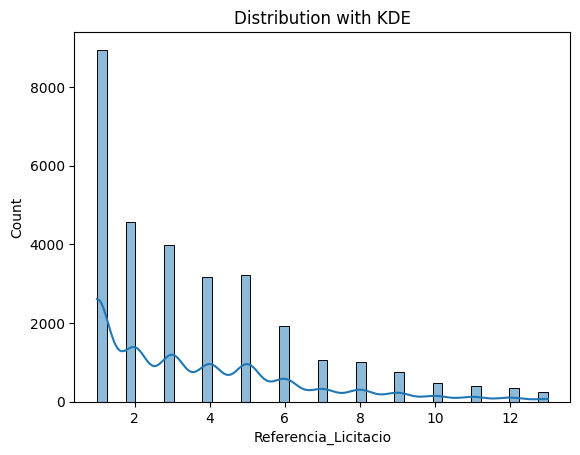

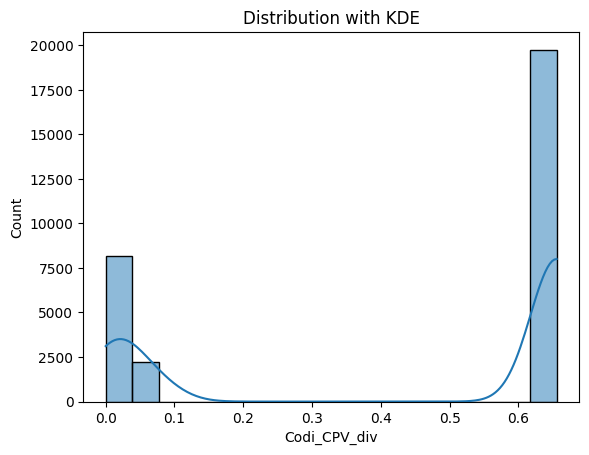

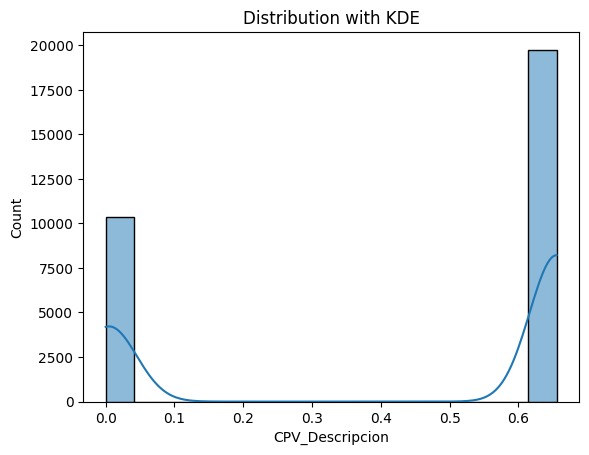

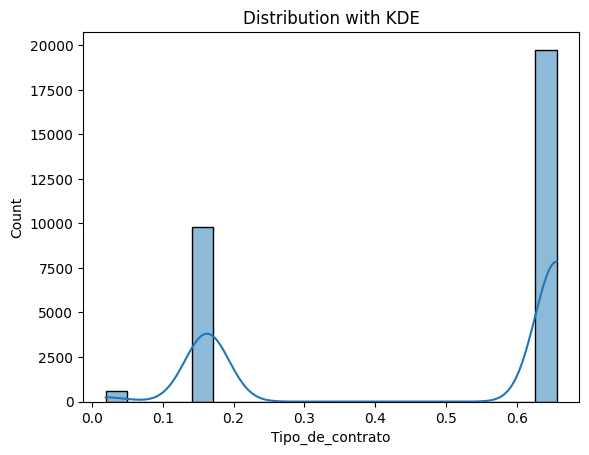

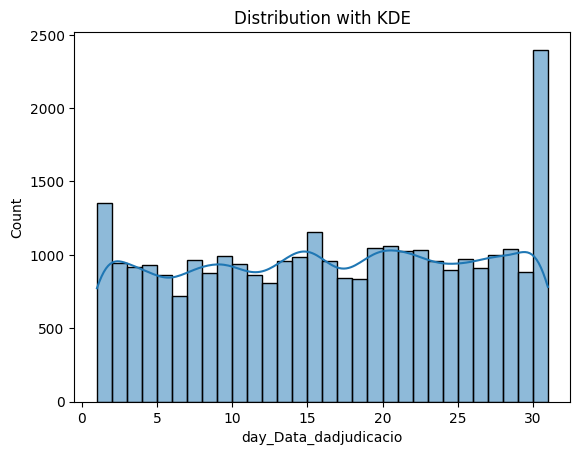

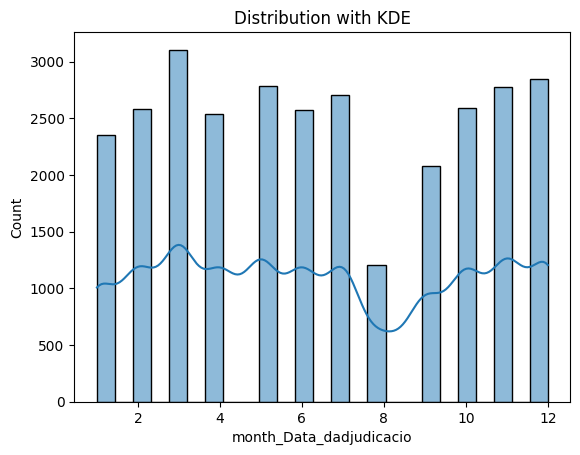

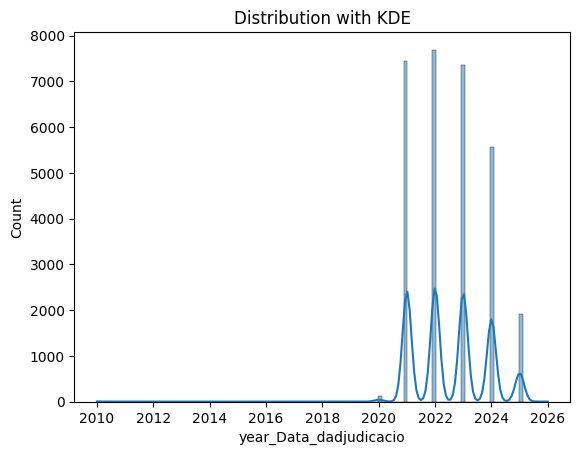

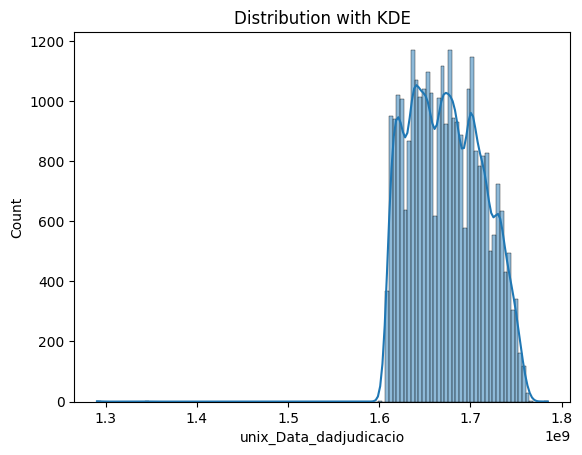

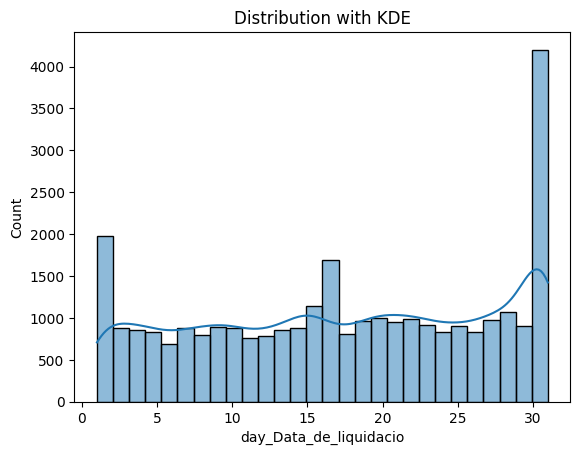

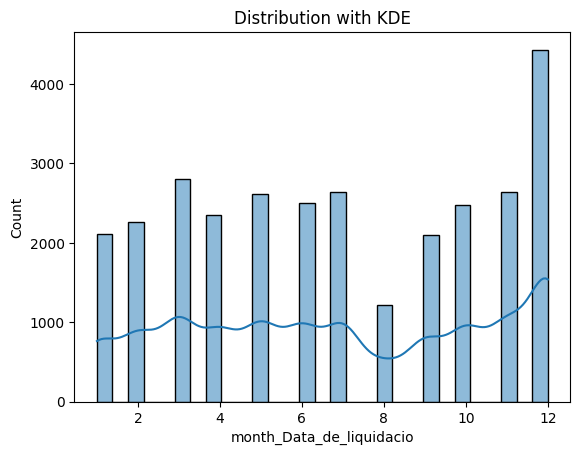

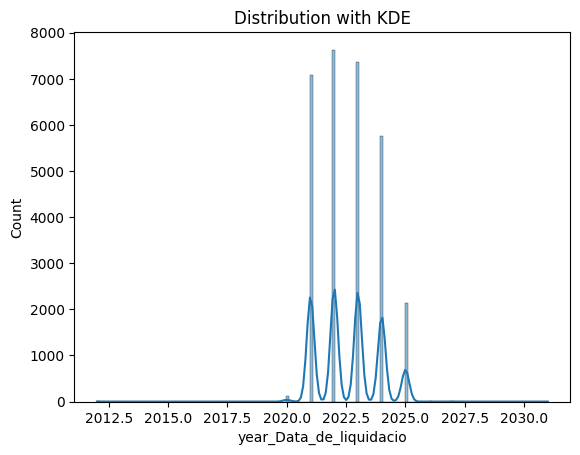

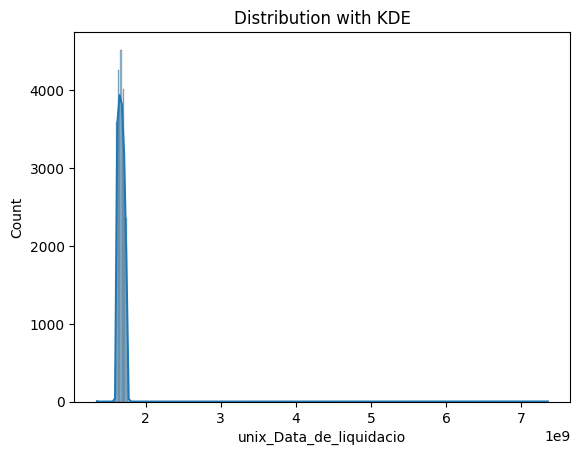

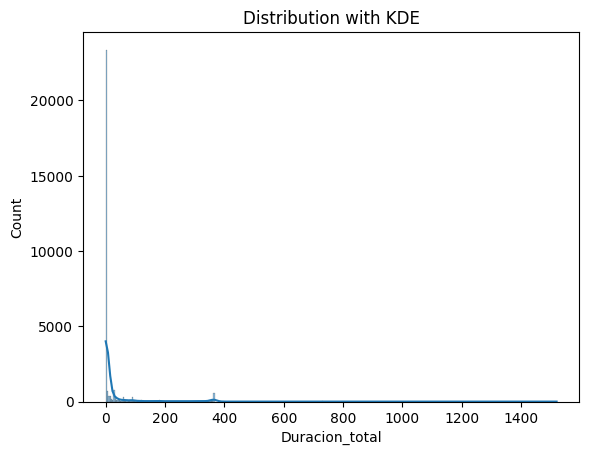

In [426]:
for feature in features_numericas:
    sns.histplot(X_train[feature], kde=True)
    plt.title('Distribution with KDE')
    plt.show()

In [427]:
'''
A partir de un analisis visual de la distribucion de cada una de las
features, podemos tratar de deducir cual de ellas necesitan una 
transformacion logaritmica, las pondremos en una lista temporalmente,
para aplicar la transformacion logaritmica en todas ellas 
La columna "Duración Total" es prácticamente nula, de momento,
usaremos una transformación log1p para evitar el error en dicha columna
'''

X_train[features_numericas] = np.log1p(X_train[features_numericas])
pipeline_steps.append(lambda df: df.assign(**{col: np.log1p(df[col]) for col in features_numericas}))

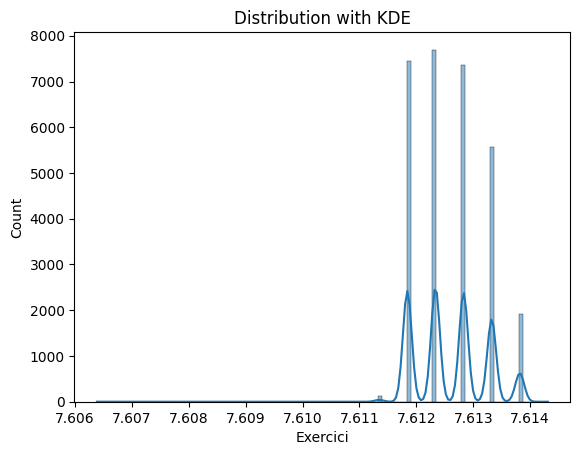

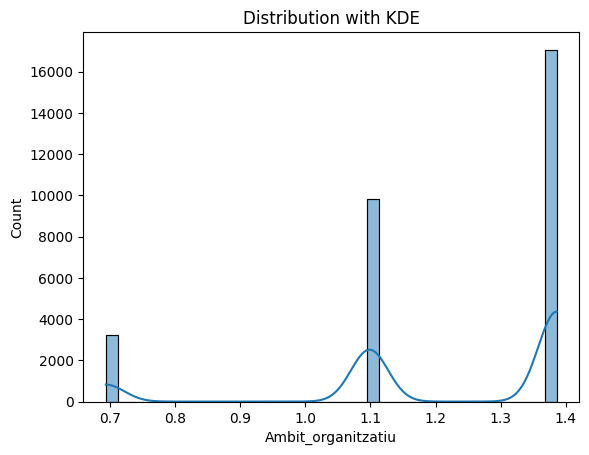

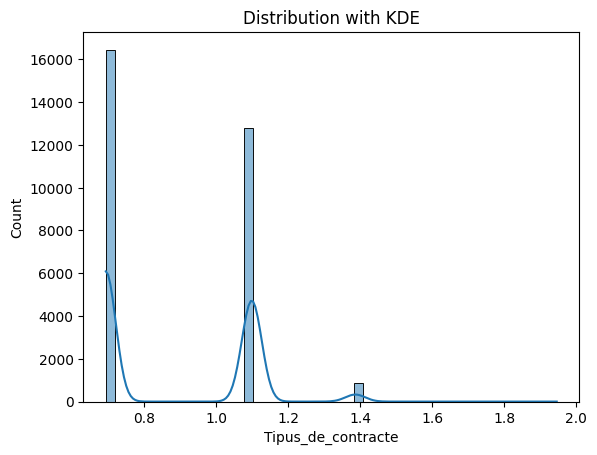

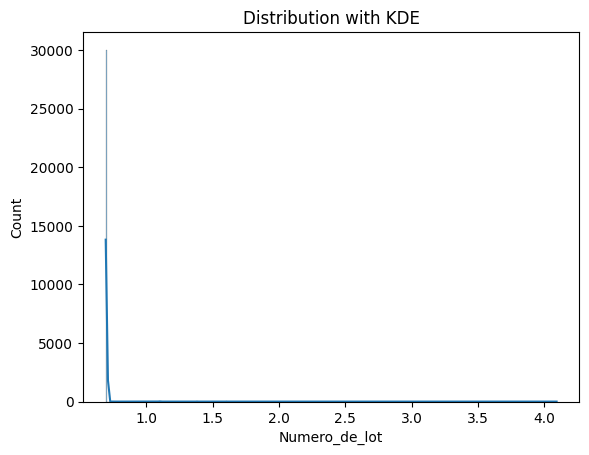

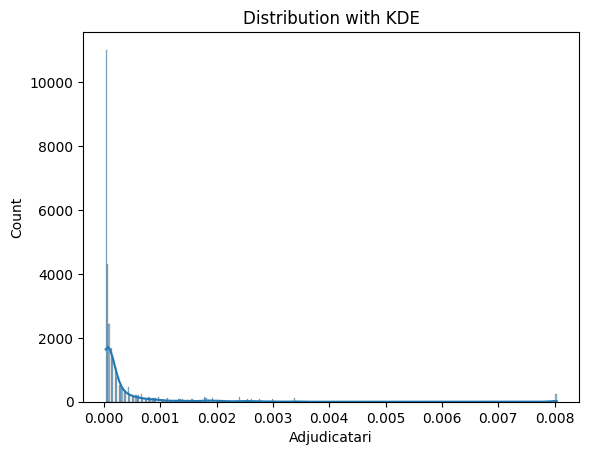

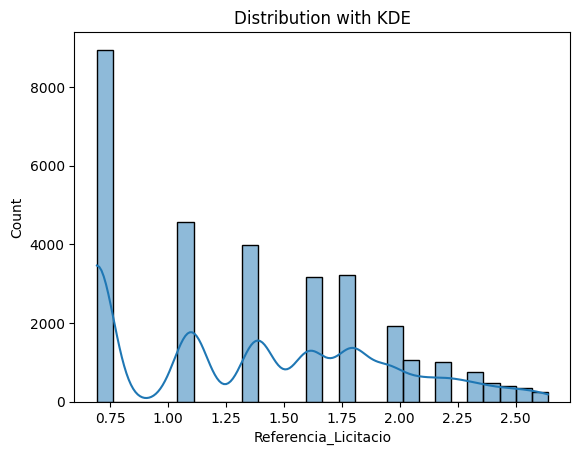

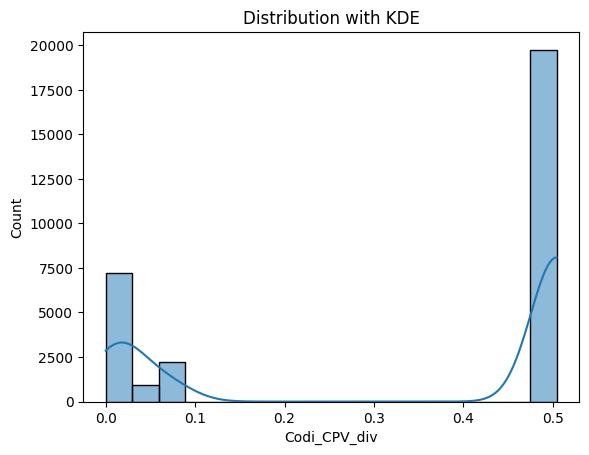

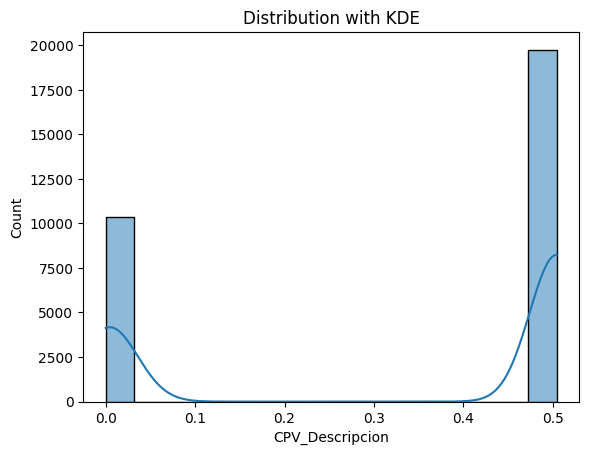

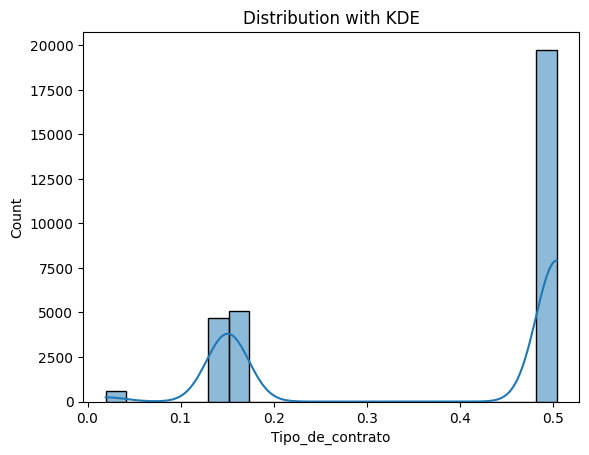

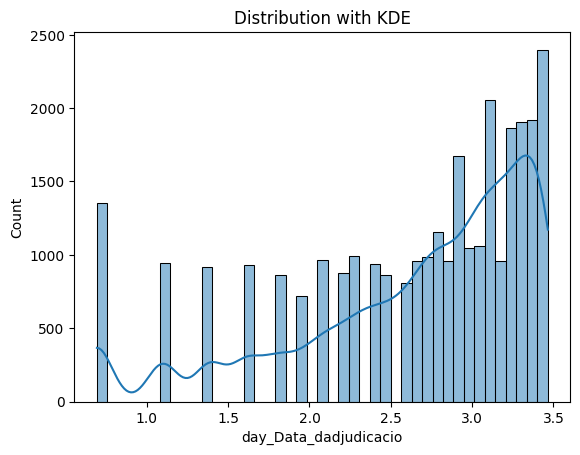

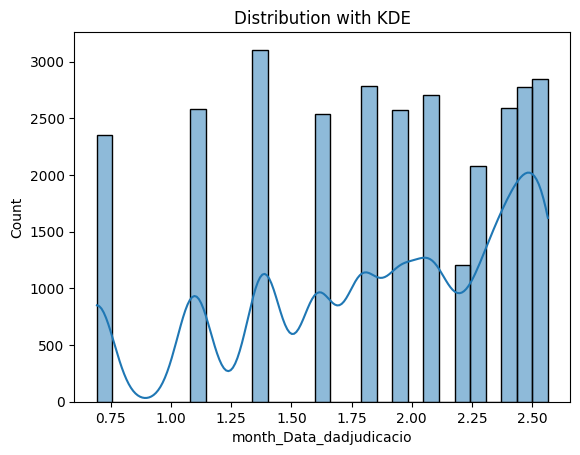

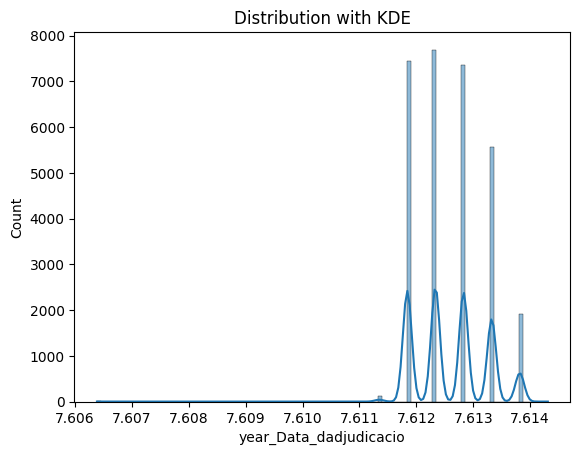

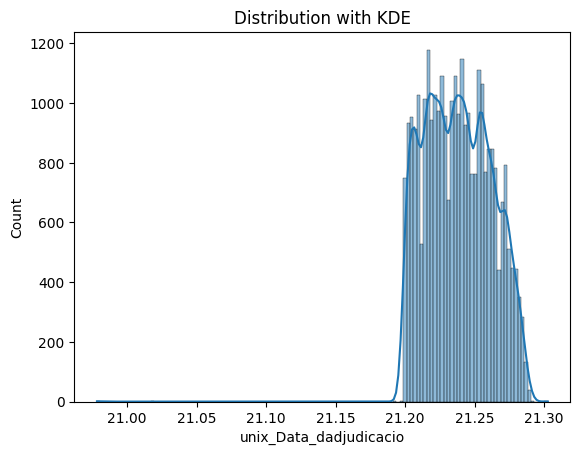

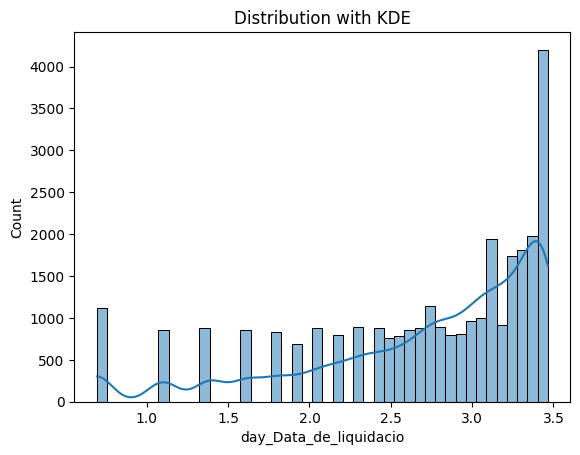

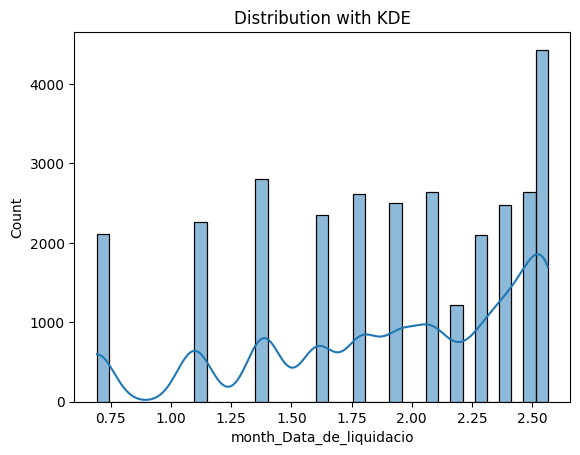

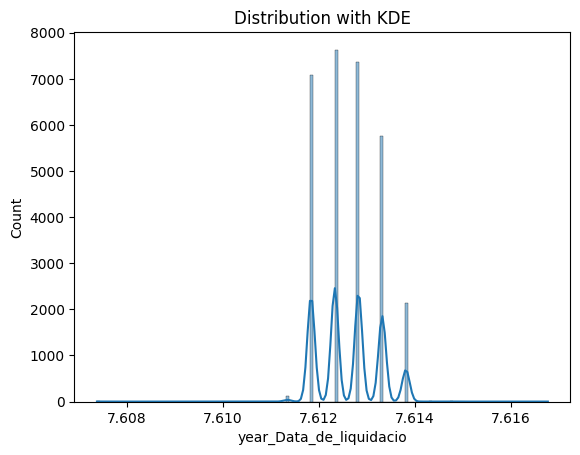

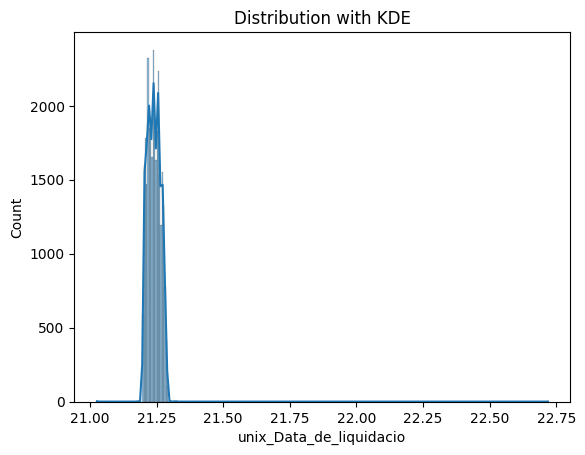

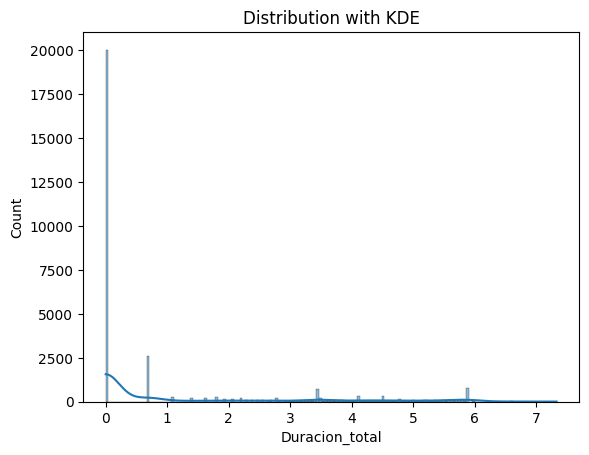

In [428]:
# Repetimos el proceso de visualización para ver el resultado de la transformación logarítmica
for feature in features_numericas:
    sns.histplot(X_train[feature], kde=True)
    plt.title('Distribution with KDE')
    plt.show()

In [429]:
# Vemos que las distribuciones no han mejorado mucho...

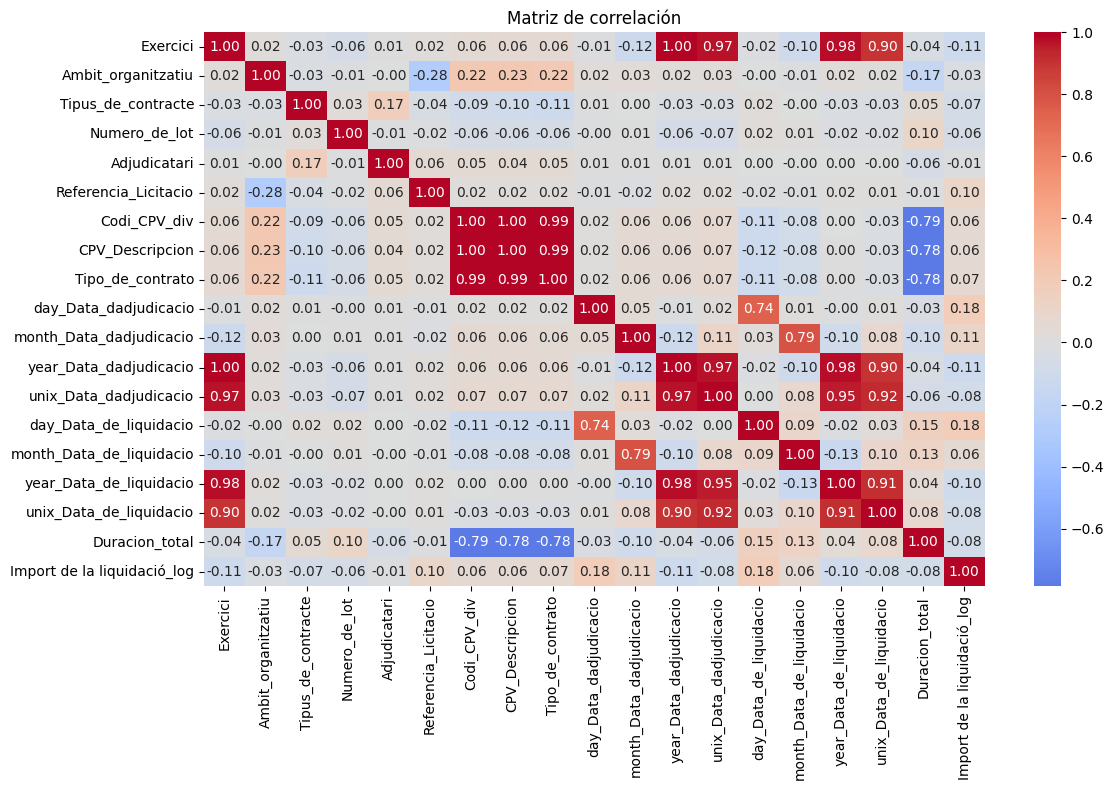

In [431]:
'''
Aqui tenemos mucha miga, asi que vamos a comentar por apartados. 

-1. Las fechas que hay entre adjudicacion y liquidacion tienen una alta colinialidad, esto puede deberse
nuevamente por muchas razones. Puede ser porque, en un caso ideal, la mayoria de licitaciones han
cumplido con los plazos que fueron establecidos inicialmente en el proceso de adjudicación, y por
ello nos encontramos muchas coincidencias. Por supuesto, no podemos permitir que nuesto sesgo actue,
pese a la surrealidad de la situación. En casos normales, pensariamos que son categorias duplicadas,
pero como en realidad tienen significancia individual las conservamos.

-2. Vemos que las fechas unix no han sido buena idea, evidentemente tiene una alta colinialidad con
el resto de features que hacen referencia a fechas, asi que por el bien del proyecto, las eliminaremos.
Lo mismo ocurre con la fecha del año de liquidacion. Si vien pueden existir diferencias de fechas entre 
adjudicacion y liquidacion, es raro que salten de año, por lo que hay una alta colianidad con el año
de la adjudicacion, tambien lo aislamos del modelo.
'''

corr_matrix = pd.concat([X_train[features_numericas], y_train], axis=1).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

In [433]:
'''
En el siguiente apartado, para decidir cuales son las variables mas acertadas como las 'principales'
haremos uso de la correlacion de spearman
'''

for feature in features_numericas:
        
    print(f"Correlación de Spearman {feature}: {correlacion_spearman}")

Correlación de Spearman Exercici: -0.06317184709356087
Correlación de Spearman Ambit_organitzatiu: -0.06317184709356087
Correlación de Spearman Tipus_de_contracte: -0.06317184709356087
Correlación de Spearman Numero_de_lot: -0.06317184709356087
Correlación de Spearman Adjudicatari: -0.06317184709356087
Correlación de Spearman Referencia_Licitacio: -0.06317184709356087
Correlación de Spearman Codi_CPV_div: -0.06317184709356087
Correlación de Spearman CPV_Descripcion: -0.06317184709356087
Correlación de Spearman Tipo_de_contrato: -0.06317184709356087
Correlación de Spearman day_Data_dadjudicacio: -0.06317184709356087
Correlación de Spearman month_Data_dadjudicacio: -0.06317184709356087
Correlación de Spearman year_Data_dadjudicacio: -0.06317184709356087
Correlación de Spearman unix_Data_dadjudicacio: -0.06317184709356087
Correlación de Spearman day_Data_de_liquidacio: -0.06317184709356087
Correlación de Spearman month_Data_de_liquidacio: -0.06317184709356087
Correlación de Spearman year_

In [434]:
# Aplicamos las modificaciones que hemos hecho sobre X_train a X_test
from functools import reduce

X_test = reduce(lambda acc, func: func(acc), pipeline_steps, X_test)



Fechas incongruentes Data_de_liquidacio: 
1289    13/11/0023
Name: Data_de_liquidacio, dtype: object

Fechas corregidas: Data_de_liquidacio
13/11/2023


In [435]:
X_test.head()

,Exercici,Ambit_organitzatiu,Procediment_dadjudicacio,Tipus_de_contracte,Numero_de_lot,Adjudicatari,Tipus_de_liquidacio,Referencia_Licitacio,Codi_CPV_div,CPV_Descripcion,Tipo_de_contrato,day_Data_dadjudicacio,month_Data_dadjudicacio,year_Data_dadjudicacio,unix_Data_dadjudicacio,day_Data_de_liquidacio,month_Data_de_liquidacio,year_Data_de_liquidacio,unix_Data_de_liquidacio,Duracion_total
0,7.611842,0.693147,True,0.693147,0.693147,0.000100,True,1.791759,0.001360,0.000266,0.145166,3.258097,0.693147,7.611842,21.200452,2.484907,1.098612,7.611842,21.201363,0.693147
1,7.612831,1.386294,True,1.098612,0.693147,0.000133,True,0.693147,0.504184,0.504184,0.504184,2.197225,1.945910,7.612831,21.245733,2.197225,1.945910,7.612831,21.245733,0.000000
2,7.611842,1.098612,True,0.693147,0.693147,NaN,True,2.079442,0.016594,0.000631,0.145166,1.386294,2.197225,7.611842,21.210587,2.079442,2.302585,7.611842,21.212442,1.791759
3,7.612337,1.386294,True,0.693147,0.693147,0.000199,True,0.693147,0.504184,0.504184,0.504184,2.079442,1.945910,7.612337,21.226801,2.079442,1.945910,7.612337,21.226801,0.000000
4,7.611842,1.098612,True,1.098612,0.693147,NaN,True,1.098612,0.070678,0.001194,0.155677,2.197225,2.302585,7.611842,21.212495,3.433987,2.302585,7.611842,21.213660,3.178054


In [436]:
rf_reg = RandomForestRegressor(max_depth = 10, random_state= 42)
lgb_reg = LGBMRegressor(max_depth = 10, random_state = 42, verbose = -1)
xgb_reg = XGBRegressor(max_depth = 10, random_state = 42)

modelos_reg = {
    "Random Forest": rf_reg,
    "LightGBM": lgb_reg,
    "XGBoost Regressor": xgb_reg
}

In [437]:
for nombre, modelo in zip(["XGBRegressor","LGBMRegressor","RandomForestRegressor"],[xgb_reg, lgb_reg, rf_reg]):
    print(f"Para {nombre}:", end = " ")
    print("neg_mean_absolute error:", np.mean(cross_val_score(modelo, X_train, y_train, cv = 5, scoring = "neg_root_mean_squared_error")))

Para XGBRegressor: neg_mean_absolute error: -1.5535421394883413
Para LGBMRegressor: neg_mean_absolute error: -1.4555848811182488
Para RandomForestRegressor: neg_mean_absolute error: -1.4632258965361065


In [ ]:
'''
Vemos que los que dan mejor resultado se tratan del lgbm y del randomforestregressor,
haremos un estudio con optuna con ambos modelos para ver que resultados nos muestran
'''

In [439]:
def objective(trial):
    param_grid = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 70),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "criterion": trial.suggest_categorical("criterion", ["squared_error", "absolute_error"]),
        "max_samples": trial.suggest_float("max_samples", 0.5, 1.0)
    }

    model = LGBMRegressor(**param_grid, random_state=42, n_jobs=-1)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    ).mean()

    return score

In [440]:
study = optuna.create_study(direction="maximize", 
                            sampler=optuna.samplers.TPESampler(seed=42))

[I 2026-03-04 15:11:54,262] A new study created in memory with name: no-name-427a3470-6020-4c07-819a-334b5798e7a9


In [441]:
study.optimize(objective, n_trials=20)

[I 2026-03-04 15:12:02,274] Trial 0 finished with value: -1.4556684845941672 and parameters: {'n_estimators': 362, 'max_depth': 67, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'squared_error', 'max_samples': 0.8540362888980227}. Best is trial 0 with value: -1.4556684845941672.
[I 2026-03-04 15:12:05,414] Trial 1 finished with value: -1.4572219241672346 and parameters: {'n_estimators': 114, 'max_depth': 68, 'min_samples_split': 17, 'min_samples_leaf': 3, 'max_features': None, 'criterion': 'squared_error', 'max_samples': 0.645614570099021}. Best is trial 0 with value: -1.4556684845941672.
[I 2026-03-04 15:12:11,131] Trial 2 finished with value: -1.4615339715844722 and parameters: {'n_estimators': 528, 'max_depth': 12, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'absolute_error', 'max_samples': 0.5232252063599989}. Best is trial 0 with value: -1.4556684845941672.
[I 2026-03-04 15:12:14,529] Trial 3 finished w

In [442]:
optuna.visualization.plot_param_importances(study)

In [443]:
optuna.visualization.plot_optimization_history(study)

In [444]:
best_params = study.best_params

In [445]:
best_n_estimators = best_params["n_estimators"]
best_max_depth = best_params["max_depth"]
best_min_samples_split = best_params["min_samples_split"]
best_min_samples_leaf = best_params["min_samples_leaf"]
best_max_features = best_params["max_features"]
best_criterion = best_params["criterion"]
best_max_samples = best_params["max_samples"]

In [446]:
best_lgbm_model = LGBMRegressor(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    min_samples_leaf=best_min_samples_leaf,
    max_features=best_max_features,
    criterion=best_criterion,
    max_samples=best_max_samples,
    random_state=42,
    n_jobs=-1
)

In [447]:
def objective(trial):
    param_grid = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 70),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "criterion": trial.suggest_categorical("criterion", ["squared_error", "absolute_error"]),
        "max_samples": trial.suggest_float("max_samples", 0.5, 1.0)
    }

    model = RandomForestRegressor(**param_grid, random_state=42, n_jobs=-1)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    ).mean()

    return score

In [448]:
study = optuna.create_study(direction="maximize", 
                            sampler=optuna.samplers.TPESampler(seed=42))

[I 2026-03-04 15:15:10,640] A new study created in memory with name: no-name-7e813ff9-949b-4a2e-a7d6-debce4f4bc75


In [449]:
'''
Me peta el ordenador si pongo muchos trials, lo limito a 10 por el bien de la
integridad de mis componentes hahaha
'''

study.optimize(objective, n_trials=10)

[I 2026-03-04 15:15:17,387] Trial 0 finished with value: -1.4777868917918304 and parameters: {'n_estimators': 362, 'max_depth': 67, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'squared_error', 'max_samples': 0.8540362888980227}. Best is trial 0 with value: -1.4777868917918304.
[I 2026-03-04 15:15:21,557] Trial 1 finished with value: -1.466087990536672 and parameters: {'n_estimators': 114, 'max_depth': 68, 'min_samples_split': 17, 'min_samples_leaf': 3, 'max_features': None, 'criterion': 'squared_error', 'max_samples': 0.645614570099021}. Best is trial 1 with value: -1.466087990536672.
[I 2026-03-04 15:15:52,515] Trial 2 finished with value: -1.4884534117051276 and parameters: {'n_estimators': 528, 'max_depth': 12, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'absolute_error', 'max_samples': 0.5232252063599989}. Best is trial 1 with value: -1.466087990536672.
[I 2026-03-04 15:16:33,534] Trial 3 finished with

In [70]:
optuna.visualization.plot_param_importances(study)

In [71]:
optuna.visualization.plot_optimization_history(study)

In [72]:
best_params = study.best_params

In [73]:
best_n_estimators = best_params["n_estimators"]
best_max_depth = best_params["max_depth"]
best_min_samples_split = best_params["min_samples_split"]
best_min_samples_leaf = best_params["min_samples_leaf"]
best_max_features = best_params["max_features"]
best_criterion = best_params["criterion"]
best_max_samples = best_params["max_samples"]

In [74]:
best_rf_model = RandomForestRegressor(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    min_samples_leaf=best_min_samples_leaf,
    max_features=best_max_features,
    criterion=best_criterion,
    max_samples=best_max_samples,
    random_state=42,
    n_jobs=-1
)

In [75]:
best_lgbm_model.fit(X_train,y_train)


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,45
,learning_rate,0.1
,n_estimators,294
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [76]:
best_rf_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",114
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",68
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",17
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [77]:
y_pred_lgbm = best_lgbm_model.predict(X_test)
y_pred_rf = best_rf_model.predict(X_test)

In [78]:
print(round(root_mean_squared_error(y_test, y_pred_lgbm),4))
print(round(root_mean_squared_error(y_test, y_pred_rf),4))


1.4196
1.4309


In [79]:
#joblib.dump(y_pred_lgbm, '../models/lgbm.pkl')


In [80]:
#joblib.dump(y_pred_rf, '../models/rf.pkl')


In [81]:
df

,Exercici,Àmbit organitzatiu,Procediment d’adjudicació,Tipus de contracte,Número de lot,Adjudicatari,Lot desert,Tipus de liquidació,Referencia_Licitació,Descripcio_CPV,mes_adj,dia_adj,Duracion_total,mes_liq,dia_liq,Import de la liquidació
0,15,2,0.0,1,0.693147,0.000956,0,0.0,3,0.656229,2,8,0.000000,2,8,1.217876
1,16,1,0.0,0,0.693147,0.000080,0,0.0,2,0.014023,11,14,0.693147,11,14,5.145632
2,17,2,0.0,1,0.693147,0.000133,0,0.0,0,0.656229,5,13,0.000000,5,13,3.846097
3,14,1,0.0,0,0.693147,0.000027,0,0.0,6,0.000266,4,15,4.499810,6,15,7.673749
4,18,2,0.0,0,0.693147,0.000027,0,0.0,0,0.656229,3,25,0.000000,3,25,6.781058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37648,16,1,0.0,0,0.693147,0.000239,0,0.0,2,0.656229,2,24,0.000000,2,24,6.832741
37649,16,2,0.0,0,0.693147,0.000106,0,0.0,5,0.656229,12,13,0.000000,12,13,7.824446
37650,14,1,0.0,0,0.693147,0.000106,0,0.0,1,0.656229,12,15,0.000000,12,15,5.398163
37651,18,1,0.0,0,0.693147,0.000027,0,0.0,1,0.000027,7,4,3.433987,8,3,8.751865


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37651 entries, 0 to 37652
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Exercici                   37651 non-null  int64  
 1   Àmbit organitzatiu         37651 non-null  int64  
 2   Procediment d’adjudicació  37651 non-null  float64
 3   Tipus de contracte         37651 non-null  int64  
 4   Número de lot              37651 non-null  float64
 5   Adjudicatari               37651 non-null  float64
 6   Lot desert                 37651 non-null  int64  
 7   Tipus de liquidació        37651 non-null  float64
 8   Referencia_Licitació       37651 non-null  int64  
 9   Descripcio_CPV             37651 non-null  float64
 10  mes_adj                    37651 non-null  int32  
 11  dia_adj                    37651 non-null  int32  
 12  Duracion_total             37651 non-null  float64
 13  mes_liq                    37651 non-null  int32  
